In [2]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

In [15]:
torch.manual_seed(42)
#Fade data - 100 ads, 3 rows each (age, budget, platform)
x = torch.randn(100,3)

#Output - engagement score ( Formula = age*2 + budget*2 + platform*1)
eng_score = (x[:, 0]*2 + x[:, 1]*2 + x[:,2]*1).unsqueeze(1)

In [16]:
#splitting the data to avoid overfitting
split = int( 0.8 * len(x))
x_train, x_test = x[:split], x[split:]
y_train, y_test = eng_score[:split], eng_score[split:]

In [10]:
#network
class AdEngagementScore(nn.Module):
  def __init__(self):
    super().__init__()
    self.network = nn.Sequential(
        nn.Linear(3, 8),
        nn.ReLU(),
        nn.Linear(8, 4),
        nn.ReLU(),
        nn.Linear(4, 1)
    )

  def forward(self, x):
    return self.network(x)

model = AdEngagementScore()
print(model)


AdEngagementScore(
  (network): Sequential(
    (0): Linear(in_features=3, out_features=8, bias=True)
    (1): ReLU()
    (2): Linear(in_features=8, out_features=4, bias=True)
    (3): ReLU()
    (4): Linear(in_features=4, out_features=1, bias=True)
  )
)


In [12]:
#Loss function with optimization
loss_fn = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr = 0.01) #assuming learning rate = 0.01

In [17]:
#training the data
checks = 200 #number of checks through the loops
losses_train = [] #record training data losses
losses_test = [] #record testing data losses

for check in range(checks):
  model.train()
  predictions = model(x_train) #forward to generate predictions

  loss = loss_fn(predictions, y_train) #compute loss

  optimizer.zero_grad() #always gradient = 0, because pytorch automatically accumulates gradience, if we dont do this, its adding to the last of checks

  loss.backward() #backward pass

  optimizer.step() #updates weight

  losses_train.append(loss.item()) #Used to graph traning process later

  #test data
  model.eval()
  with torch.no_grad():
    test_predictions = model(x_test)
    test_loss = loss_fn(test_predictions, y_test)
    losses_test.append(test_loss.item())

  if check % 20 == 0:
    print(f"Check {check}, Train Loss: {loss.item():.4f}, Test Loss: {test_loss.item():.4f} ") #prints updates after 20 checks



Check 0, Train Loss: 0.0367, Test Loss: 0.0416 
Check 20, Train Loss: 0.0091, Test Loss: 0.0229 
Check 40, Train Loss: 0.0044, Test Loss: 0.0175 
Check 60, Train Loss: 0.0027, Test Loss: 0.0138 
Check 80, Train Loss: 0.0020, Test Loss: 0.0120 
Check 100, Train Loss: 0.0017, Test Loss: 0.0112 
Check 120, Train Loss: 0.0015, Test Loss: 0.0107 
Check 140, Train Loss: 0.0014, Test Loss: 0.0102 
Check 160, Train Loss: 0.0014, Test Loss: 0.0098 
Check 180, Train Loss: 0.0013, Test Loss: 0.0095 


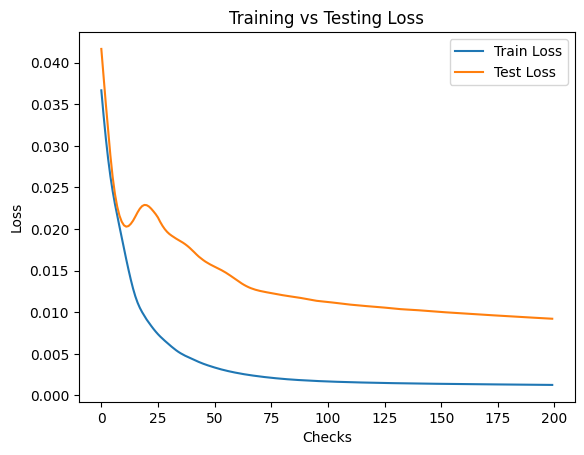

In [19]:
#Plot the loss
plt.plot(losses_train, label = 'Train Loss')
plt.plot(losses_test, label = 'Test Loss')
plt.xlabel("Checks")
plt.ylabel("Loss")
plt.title("Training vs Testing Loss")
plt.legend()
plt.show()